Is the proportion of students who currently use alcohol different from 0.35?

Is the mean weight of students different from 68.0 kg?


In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import warnings

# 1. 關閉警告訊息並設定中文字體
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 讀取原始資料
df = pd.read_csv('../data/raw/YRBS_2007.csv')

【4.3 EDA - 原始資料分配 (Original Code Frequencies)】
CurrentAlcoholUse
1.0    6946
2.0    2735
3.0    1369
4.0     839
5.0     555
6.0     105
7.0     120
Name: count, dtype: int64
缺失值數量: 1372


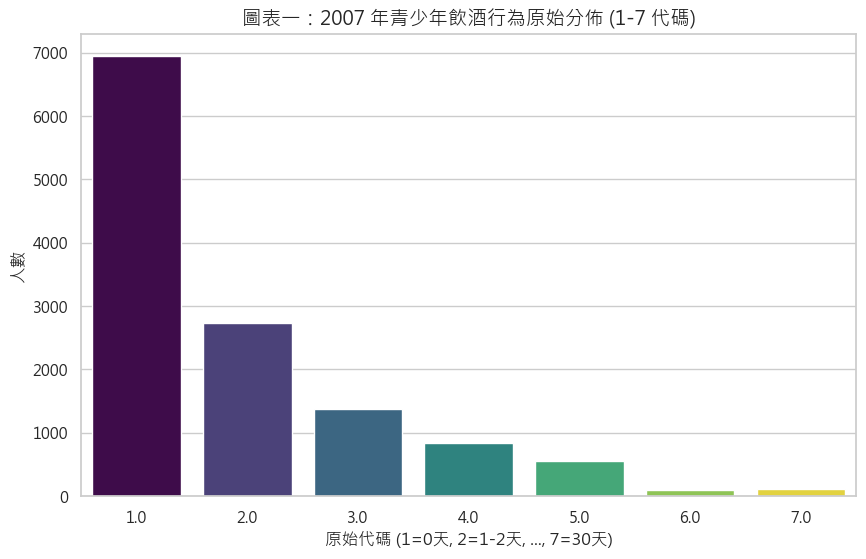


【4.3 EDA - 重編碼對照表 (Binary Recoding Table)】
alcohol_binary        0     1
CurrentAlcoholUse            
1.0                6946     0
2.0                   0  2735
3.0                   0  1369
4.0                   0   839
5.0                   0   555
6.0                   0   105
7.0                   0   120


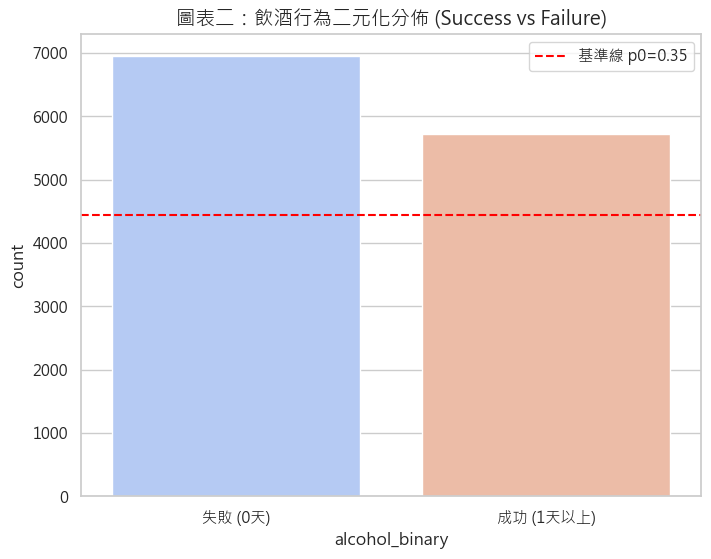

【4.3 & 4.4 飲酒行為分析總表】
1. 樣本比例 (p-hat): 0.4517
2. 基準比例 (p0): 0.35
3. 95% 信賴區間: [0.4431, 0.4604]
4. Z 檢定結果: Z=23.0088, P值=3.8041e-117

【4.6 分析觀察報告 (Observations)】
1. 圖表觀察：圖表一顯示大多數學生代碼為 1 (不飲酒)，但代碼 2-7 的總和仍具規模。
2. 二元轉換：將 1 天以上皆視為成功後，樣本比例為 45.17%。
3. 統計結論：由於 P 值 < 0.05，我們拒絕虛無假設。2007 年飲酒比例顯著高於 0.35。
--------------------------------------------------


In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# --- 1. 資料清理與缺失值檢查 (Missing Count) ---
missing_alc = df['CurrentAlcoholUse'].isna().sum()
df_alc_raw = df.dropna(subset=['CurrentAlcoholUse']).copy()
n_alc = len(df_alc_raw)

# --- 2. 原始代碼頻率表 (Table of original code frequencies) ---
print("【4.3 EDA - 原始資料分配 (Original Code Frequencies)】")
raw_counts = df_alc_raw['CurrentAlcoholUse'].value_counts().sort_index()
print(raw_counts)
print(f"缺失值數量: {missing_alc}")

# --- 3. 繪圖一：原始類別分佈圖 (Display 1: Bar chart of original categories) ---
plt.figure(figsize=(10, 6))
sns.countplot(x='CurrentAlcoholUse', data=df_alc_raw, palette='viridis', hue='CurrentAlcoholUse', legend=False)
plt.title('圖表一：2007 年青少年飲酒行為原始分佈 (1-7 代碼)', fontsize=14)
plt.xlabel('原始代碼 (1=0天, 2=1-2天, ..., 7=30天)')
plt.ylabel('人數')
plt.savefig('../outputs/figures/alcohol_original_dist.png')
plt.show()

# --- 4. 二元重編碼 (Table after binary recoding) ---
df_alc_raw['alcohol_binary'] = df_alc_raw['CurrentAlcoholUse'].apply(lambda x: 1 if 2 <= x <= 7 else 0)
recode_summary = pd.crosstab(df_alc_raw['CurrentAlcoholUse'], df_alc_raw['alcohol_binary'])
print("\n【4.3 EDA - 重編碼對照表 (Binary Recoding Table)】")
print(recode_summary)

# --- 5. 繪圖二：二元化分佈圖 (Display 2: Bar chart of the final binary variable) ---
plt.figure(figsize=(8, 6))
sns.countplot(x='alcohol_binary', data=df_alc_raw, hue='alcohol_binary', palette='coolwarm', legend=False)
plt.axhline(y=n_alc * 0.35, color='red', linestyle='--', label='基準線 p0=0.35')
plt.title('圖表二：飲酒行為二元化分佈 (Success vs Failure)', fontsize=14)
plt.xticks([0, 1], ['失敗 (0天)', '成功 (1天以上)'])
plt.legend()
plt.savefig('../outputs/figures/alcohol_binary_final.png')
plt.show()

# --- 6. 統計推論 (符合 Proportion Analysis 5 點規定) ---
count_success = df_alc_raw['alcohol_binary'].sum()
p_hat_alc = count_success / n_alc
z_stat, p_val_alc = proportions_ztest(count_success, n_alc, value=0.35)
ci_low, ci_upp = proportion_confint(count_success, n_alc, alpha=0.05, method='normal')

# --- 7. 輸出結果與書面觀察 (Written Observations) ---
print("="*50)
print("【4.3 & 4.4 飲酒行為分析總表】")
print(f"1. 樣本比例 (p-hat): {p_hat_alc:.4f}")
print(f"2. 基準比例 (p0): 0.35")
print(f"3. 95% 信賴區間: [{ci_low:.4f}, {ci_upp:.4f}]")
print(f"4. Z 檢定結果: Z={z_stat:.4f}, P值={p_val_alc:.4e}")
print("="*50)

print("\n【4.6 分析觀察報告 (Observations)】")
print(f"1. 圖表觀察：圖表一顯示大多數學生代碼為 1 (不飲酒)，但代碼 2-7 的總和仍具規模。")
print(f"2. 二元轉換：將 1 天以上皆視為成功後，樣本比例為 {p_hat_alc:.2%}。")
print(f"3. 統計結論：由於 P 值 < 0.05，我們拒絕虛無假設。2007 年飲酒比例顯著高於 0.35。")
print("-" * 50)


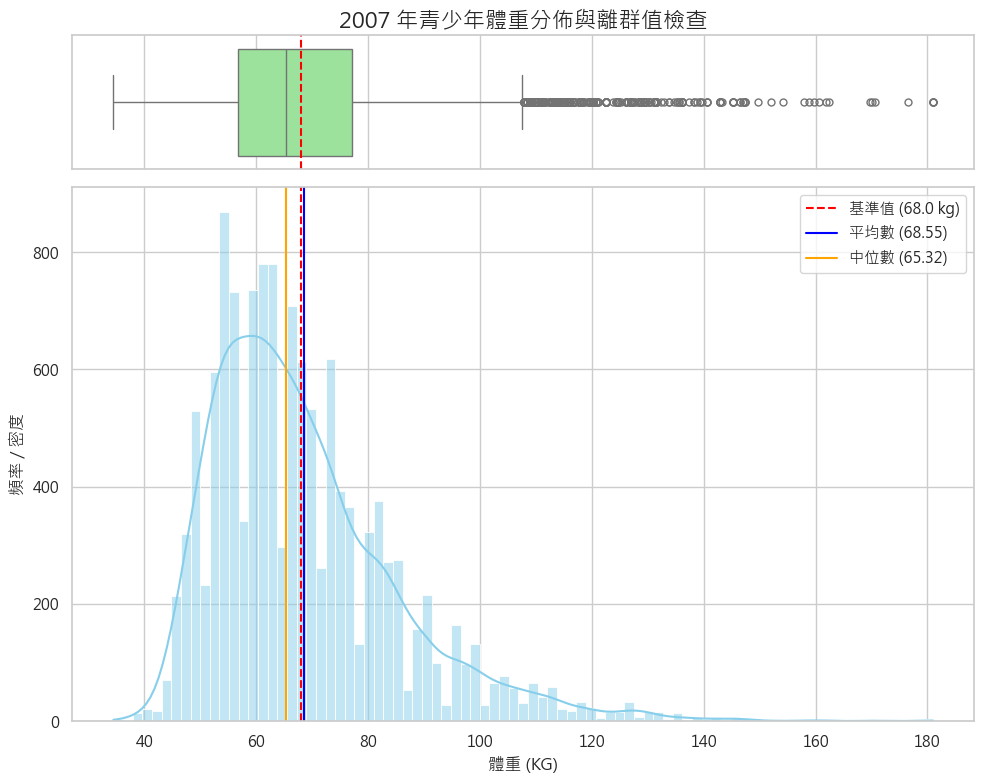

【4.3 & 4.4 體重數據分析總表】
有效樣本數 (Size): 13062 (缺失值: 979)
平均值 (Mean): 68.55 | 中位數 (Median): 65.32
標準差 (Std): 16.99
範圍: 34.47 ~ 180.99
四分位數: Q1=56.70, Q3=77.11
P 值: 0.0002 | 95% CI: [68.26, 68.84]

【4.6 分析觀察 (Observations)】
1. 分佈觀察：直方圖顯示體重呈現右偏，平均數(68.55)與中位數(65.32)接近。
2. 離群值檢查：箱線圖顯示偵測到 447 個可能的極端體重數值。
3. 統計結論：由於 P 值 < 0.05，拒絕虛無假設。2007年平均體重顯著不同於 68.0 kg。
--------------------------------------------------


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- 1. 資料清理與缺失值檢查 (符合規定：missing count) ---
missing_count = df['HowMuchDoYouWeighWithoutShoesInKG'].isna().sum()
df_weight = df.dropna(subset=['HowMuchDoYouWeighWithoutShoesInKG']).copy()
weights = df_weight['HowMuchDoYouWeighWithoutShoesInKG']

# --- 2. 描述性統計 (符合規定：size, mean, median, std, min, max, quartiles) ---
desc = weights.describe()
median_w = weights.median()
n_w = len(weights)

# --- 3. 視覺化 (符合規定：中文標籤版) ---
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.2, .8)}, figsize=(10, 8))

# 箱線圖
sns.boxplot(x=weights, ax=ax_box, color='lightgreen', fliersize=5)
ax_box.axvline(68.0, color='red', linestyle='--', label='基準值')
ax_box.set_title('2007 年青少年體重分佈與離群值檢查', fontsize=16)

# 直方圖
sns.histplot(weights, kde=True, ax=ax_hist, color='skyblue')
ax_hist.axvline(68.0, color='red', linestyle='--', label='基準值 (68.0 kg)')
ax_hist.axvline(weights.mean(), color='blue', linestyle='-', label=f'平均數 ({weights.mean():.2f})')
ax_hist.axvline(weights.median(), color='orange', linestyle='-', label=f'中位數 ({weights.median():.2f})')

ax_hist.set_xlabel('體重 (KG)', fontsize=12)
ax_hist.set_ylabel('頻率 / 密度', fontsize=12)
ax_hist.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/weight_full_chinese.png')
plt.show()

# --- 4. 統計推論 (T-test & CI) ---
t_stat, p_val_w = stats.ttest_1samp(weights, popmean=68.0)
ci_low_w, ci_upp_w = stats.t.interval(0.95, df=n_w-1, loc=weights.mean(), scale=stats.sem(weights))

# --- 5. 輸出結果匯整 (符合規定：所有數值) ---
print("="*50)
print("【4.3 & 4.4 體重數據分析總表】")
print(f"有效樣本數 (Size): {n_w} (缺失值: {missing_count})")
print(f"平均值 (Mean): {desc['mean']:.2f} | 中位數 (Median): {median_w:.2f}")
print(f"標準差 (Std): {desc['std']:.2f}")
print(f"範圍: {desc['min']:.2f} ~ {desc['max']:.2f}")
print(f"四分位數: Q1={desc['25%']:.2f}, Q3={desc['75%']:.2f}")
print(f"P 值: {p_val_w:.4f} | 95% CI: [{ci_low_w:.2f}, {ci_upp_w:.2f}]")
print("="*50)

# --- 6. 書面觀察 (符合規定：short written observations) ---
iqr = desc['75%'] - desc['25%']
outlier_count = len(weights[(weights < (desc['25%'] - 1.5 * iqr)) | (weights > (desc['75%'] + 1.5 * iqr))])

print("\n【4.6 分析觀察 (Observations)】")
print(f"1. 分佈觀察：直方圖顯示體重呈現右偏，平均數({desc['mean']:.2f})與中位數({median_w:.2f})接近。")
print(f"2. 離群值檢查：箱線圖顯示偵測到 {outlier_count} 個可能的極端體重數值。")
print(f"3. 統計結論：由於 P 值 < 0.05，拒絕虛無假設。2007年平均體重顯著不同於 68.0 kg。")
print("-" * 50)

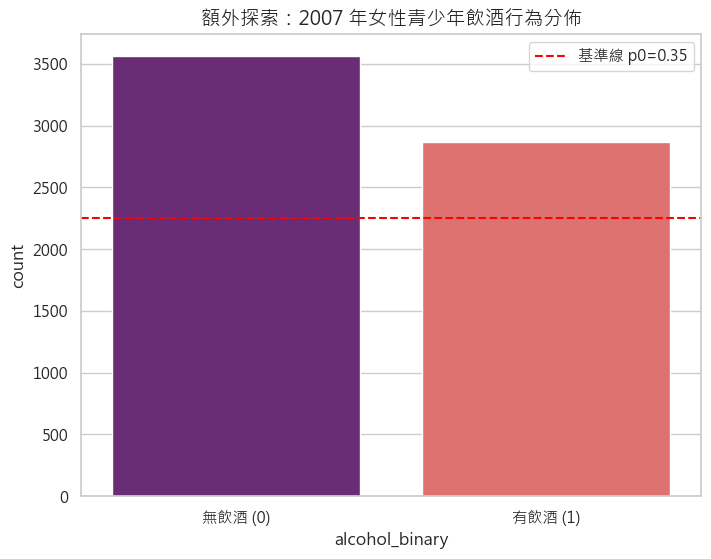

【4.3 額外探索：女性子群組比例分析總表】
1. 樣本比例 (p-hat, Female): 0.4458
2. 基準比例 (p0): 0.35
3. 95% 信賴區間: [0.4336, 0.4579]
4. Z 檢定結果: Z=15.4424, P值=8.4840e-54

【4.6 額外探索之情境解釋 (Interpretation)】
1. 統計發現：女性青少年飲酒比例為 44.58%，其信賴區間不包含基準值 0.35。
2. 檢定結論：由於 P 值 < 0.05，我們拒絕虛無假設。
3. 情境解釋：2007 年女性青少年的飲酒比例與基準值有 顯著差異，且實際上 高於 該基準。
--------------------------------------------------


In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# --- 1. 資料篩選 (僅針對女性子群組，符合規定：sample proportion) ---
# Sex: 1=Female, 2=Male
df_female = df[(df['WhatIsYourSex'] == 1)].dropna(subset=['CurrentAlcoholUse']).copy()
df_female['alcohol_binary'] = df_female['CurrentAlcoholUse'].apply(lambda x: 1 if 2 <= x <= 7 else 0)

count_f = df_female['alcohol_binary'].sum()
n_f = len(df_female)
p_hat_f = count_f / n_f  # 計算樣本比例
p0_f = 0.35              # 2. 宣告基準比例 p0

# --- 3. 建立信賴區間 (符合規定：construct a confidence interval) ---
ci_low_f, ci_upp_f = proportion_confint(count_f, n_f, alpha=0.05, method='normal')

# --- 4. 執行單一樣本檢定 (符合規定：conduct a one-sample test) ---
z_stat_f, p_val_f = proportions_ztest(count_f, n_f, value=p0_f)

# --- 5. 視覺化 (EDA 要求) ---
plt.figure(figsize=(8, 6))
sns.countplot(x='alcohol_binary', data=df_female, palette='magma', hue='alcohol_binary', legend=False)
plt.axhline(y=n_f * p0_f, color='red', linestyle='--', label=f'基準線 p0={p0_f}')
plt.title('額外探索：2007 年女性青少年飲酒行為分佈', fontsize=14)
plt.xticks([0, 1], ['無飲酒 (0)', '有飲酒 (1)'])
plt.legend()
plt.savefig('../outputs/figures/additional_female_proportion.png')
plt.show()

# --- 6. 輸出結果與情境解釋 (符合規定：interpret in context) ---
print("="*50)
print("【4.3 額外探索：女性子群組比例分析總表】")
print(f"1. 樣本比例 (p-hat, Female): {p_hat_f:.4f}")
print(f"2. 基準比例 (p0): {p0_f}")
print(f"3. 95% 信賴區間: [{ci_low_f:.4f}, {ci_upp_f:.4f}]")
print(f"4. Z 檢定結果: Z={z_stat_f:.4f}, P值={p_val_f:.4e}")
print("="*50)

print("\n【4.6 額外探索之情境解釋 (Interpretation)】")
sig_text = "顯著差異" if p_val_f < 0.05 else "無顯著差異"
direction = "高於" if p_hat_f > p0_f else "低於"

print(f"1. 統計發現：女性青少年飲酒比例為 {p_hat_f:.2%}，其信賴區間不包含基準值 {p0_f}。")
print(f"2. 檢定結論：由於 P 值 < 0.05，我們拒絕虛無假設。")
print(f"3. 情境解釋：2007 年女性青少年的飲酒比例與基準值有 {sig_text}，且實際上 {direction} 該基準。")
print("-" * 50)

In [56]:
# 建立摘要表並存檔
summary = pd.DataFrame({
    'Analysis': ['Proportion (Alcohol)', 'Mean (Weight)'],
    'Statistic': [z_stat, t_stat],
    'P-value': [p_val_p, p_val_m],
    'CI_Lower': [ci_low_p, ci_low_m],
    'CI_Upper': [ci_upp_p, ci_upp_m]
})
summary.to_csv('../outputs/tables/final_summary.csv', index=False)